# exp05_multinodo_victoria — XGBoost pooled (bloque de nodos)

Multi-nodo: un solo XGBoost entrenado con un bloque de nodos alrededor de Cd.
Victoria (pivote 1736). El nodo se describe con lat/lon/msnm (nunca con el id).
Feature-set base+nocturno.

- **v1**: bloque 5×5 (25 nodos).
- **v2** (por defecto): bloque 12×12 (**144 nodos**) — mide el efecto de escalar.

Reproducir: `python -m forecasting.experiments.run exp05_multinodo_victoria --version v2`.
Escalado observado: single 0.061 → 25 nodos 0.070 → 144 nodos ~0.085.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../..'))
import matplotlib.pyplot as plt
import pandas as pd
from forecasting.experiments.reporte import ReporteExperimento
from forecasting.data.loaders import cargar_metadata

# Cambia a version='v1' para el bloque 5×5 (25 nodos).
r = ReporteExperimento.de('exp05_multinodo_victoria', version='v2', ejecutar=False)
r.resumen()
print('multinodo:', r.es_multinodo, '| nodos:', r.config['n_nodos'])

exp05_multinodo_victoria v2 | feature-set base-nocturno (44 feats) | best_iter 294
Test global: RMSE 79.12 vs persist 86.41 | skill 0.0844 | R² 0.927
multinodo: True | nodos: 144


## Métricas pooled (val + test) vs persistence

In [2]:
r.metrics_global.round(3)

,segmento,n,RMSE_persistence,RMSE_modelo,MAE_modelo,MBE_modelo,R2_persistence,R2_modelo,skill,split
0,global,592312,86.705,78.437,43.488,3.924,0.917,0.932,0.095,val
1,limpio_ff0,539027,88.111,79.649,44.043,3.134,0.909,0.925,0.096,val
2,rellenado_ff_pos,53285,70.935,64.921,37.869,11.918,0.862,0.884,0.085,val
3,global,593770,86.414,79.118,46.684,1.841,0.913,0.927,0.084,test
4,limpio_ff0,538873,87.952,80.650,47.890,1.797,0.903,0.919,0.083,test
5,rellenado_ff_pos,54897,69.529,62.105,34.841,2.281,0.874,0.900,0.107,test


## Skill por nodo — ¿el modelo pooled generaliza a todo el bloque?

Un solo modelo, evaluado en cada nodo por separado. Tabla + mapa espacial.

skill por nodo: medio 0.0843  min 0.0591  max 0.1056  (144 nodos)


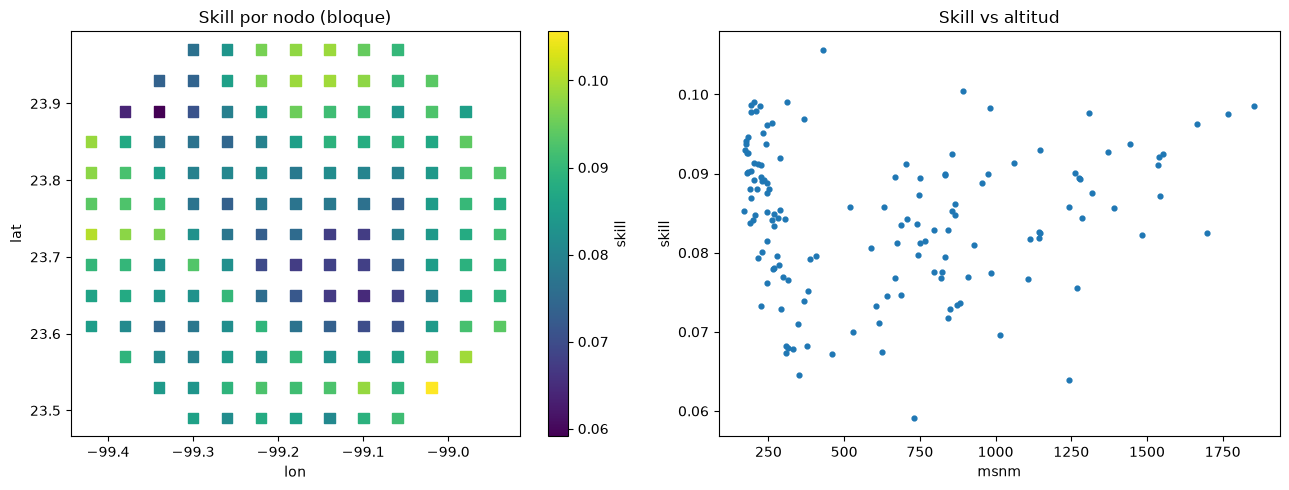

In [3]:
pn = r.por_nodo.copy()
print('skill por nodo: medio %.4f  min %.4f  max %.4f  (%d nodos)' % (
    pn.skill.mean(), pn.skill.min(), pn.skill.max(), len(pn)))
meta = cargar_metadata(pn.nodo_id.tolist())
pn = pn.merge(meta[['nodo_id','latitude','longitude','msnm']], on='nodo_id')
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
sc = ax[0].scatter(pn.longitude, pn.latitude, c=pn.skill, cmap='viridis', s=60, marker='s')
fig.colorbar(sc, ax=ax[0], label='skill'); ax[0].set_title('Skill por nodo (bloque)')
ax[0].set_xlabel('lon'); ax[0].set_ylabel('lat')
ax[1].scatter(pn.msnm, pn.skill, s=12); ax[1].set_xlabel('msnm'); ax[1].set_ylabel('skill')
ax[1].set_title('Skill vs altitud'); plt.tight_layout(); plt.show()

## Métricas por régimen (test, pooled)

In [4]:
display(r.regimen_nubosidad.round(3))
display(r.regimen_rampa.round(3))

,regimen_nubosidad,n,RMSE_modelo,RMSE_persistence,MAE_modelo,R2_modelo,skill
0,cubierto (kt<0.3),40469,148.003,141.400,109.227,-4.109,-0.047
1,parcial (0.3-0.7),104991,112.965,127.592,79.939,0.562,0.115
2,despejado (kt>=0.7),448310,57.661,65.366,33.249,0.956,0.118


,regimen_rampa,n,RMSE_modelo,RMSE_persistence,MAE_modelo,R2_modelo,skill
0,rampa suave (<0.1),408158,39.354,23.693,24.998,0.981,-0.661
1,rampa moderada (0.1-0.25),112163,93.027,101.933,72.948,0.866,0.087
2,rampa fuerte (>0.25),73305,169.814,203.620,127.282,0.394,0.166


## Importancia de features

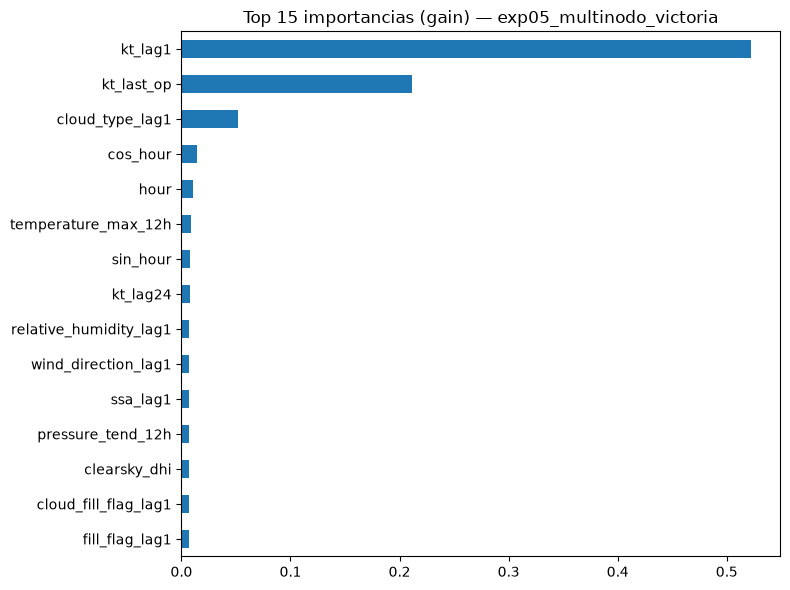

In [5]:
r.plot_importancias(15); plt.tight_layout(); plt.show()

## Series y dispersión en el nodo 1736 (el pooled visto en un nodo)

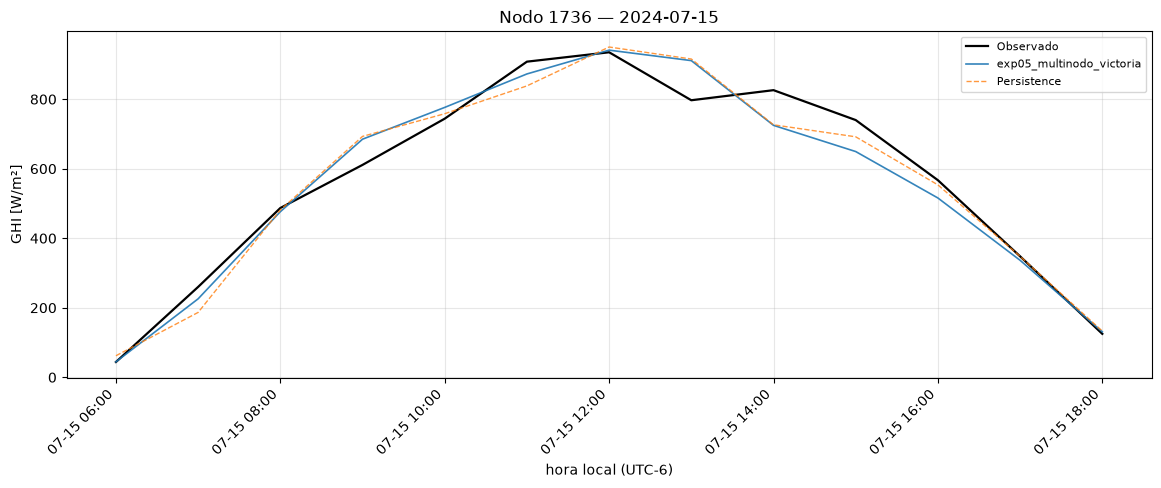

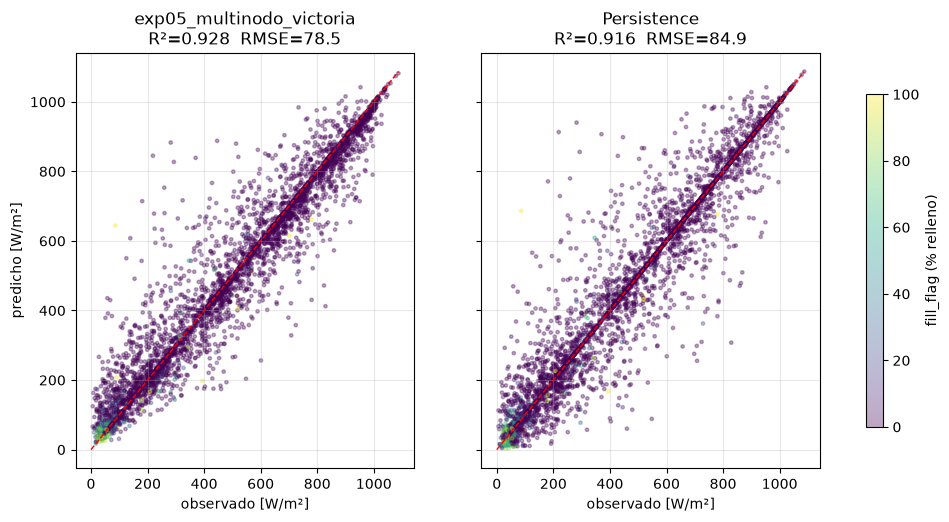

In [6]:
viz = r.visualizador(nodo=1736)
viz.serie_temporal(dia='2024-07-15'); plt.title('Nodo 1736 — 2024-07-15'); plt.show()
viz.dispersion(); plt.show()